## Pengelompokan Tingkat Keparahan Luka Diabetes dari Citra Kaki Menggunakan CNN dan K-Means


## Setup Google Colab

Cell di bawah hanya aktif jika notebook ini dibuka di Google Colab. Jika dijalankan di lokal, cell ini tidak akan melakukan apa-apa.

In [1]:
import importlib.util

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from pathlib import Path

    REPO_URL = "https://github.com/musyaree/fp-kcv.git"
    REPO_DIR = Path("/content/fp-kcv")

    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}

    %cd {REPO_DIR}/notebook

    raw_dir = REPO_DIR / "data" / "raw"
    if not raw_dir.exists() or not any(raw_dir.iterdir()):
        !python ../download_data.py
else:
    print("Bukan di Colab, lewati setup Colab.")

Bukan di Colab, lewati setup Colab.


## Tahap 0. Setup

In [2]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from data_prep import eda, preprocess, split_dataset, subset_dataset

## Tahap 1. Pengumpulan dan Eksplorasi Dataset (EDA)

### 1.1 Mengunduh Dataset & Mengambil Subset

Dataset, Diabetic Foot Ulcer, diunduh terpisah dengan menjalankan `download_data.py`. Kita mengambil subset seimbang, yaitu 250 Abnormal dan 250 Normal, dari folder `Patches/` yang sudah berlabel.

In [3]:
subset_dataset.main(argv=[])

Abnormal: 250 gambar disalin ke data/processed/subset/Abnormal
Normal: 250 gambar disalin ke data/processed/subset/Normal

Total: 500 gambar. Manifest disimpan di data/processed/subset/manifest.csv


### 1.2 Eksplorasi Data (EDA)

Cek jumlah gambar per kategori, lihat statistik ukurannya, lalu tampilkan beberapa sampel visual agar variasi data terlihat.

=== EDA Summary — Subset DFU ===

Jumlah gambar per kategori:
  Abnormal: 250
  Normal: 250
  Total: 500

Statistik ukuran gambar:
  Width  : min=220, max=330
  Height : min=220, max=330
  Ukuran unik: [(220, 220), (224, 224), (224, 244), (227, 227), (283, 280), (304, 294), (310, 316), (330, 330)]

Sampel visual disimpan di: outputs/eda_sample_grid.png
Sumber dataset: Kaggle Diabetic Foot Ulcer (DFU) Dataset (Laith Jj)
https://www.kaggle.com/datasets/laithjj/diabetic-foot-ulcer-dfu

Grid sampel disimpan di: outputs/eda_sample_grid.png


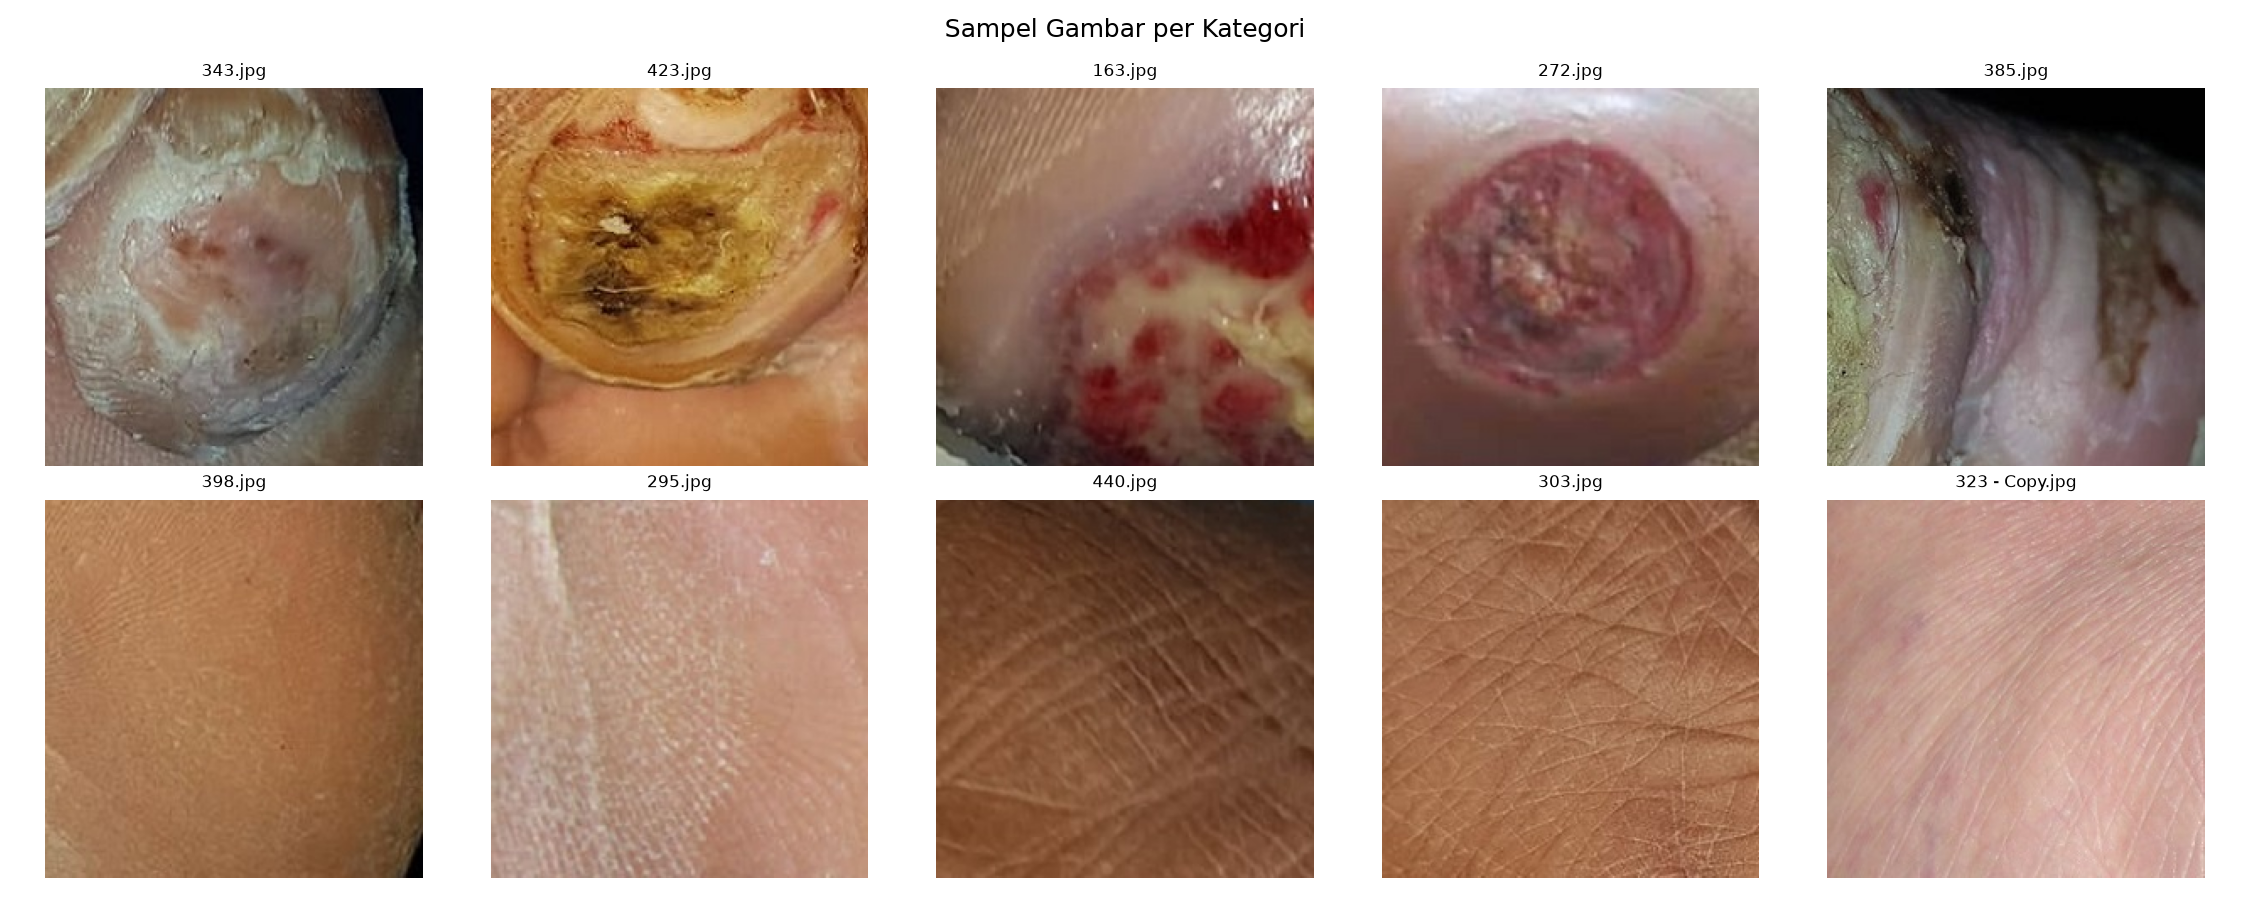

In [4]:
from IPython.display import Image, display

eda.main()
display(Image(filename=str(eda.OUTPUTS_DIR / "eda_sample_grid.png")))

## Tahap 2. Pra-pemrosesan Citra

### 2.1 Standardisasi Ukuran, Format, dan Normalisasi

Pre-Process CNN: resize semua gambar ke ukuran 224x224, lalu normalisasi memakai mean/std ImageNet.
Pre-Process Handcrafted: Konversi ke HSV menggunakan skala 0-1.

In [5]:
preprocess.main()

Selesai preprocessing.


### 2.2 Split Data Latih dan Data Uji

Split 80:20 per kategori, supaya proporsi Normal dan Abnormal tetap seimbang di kedua sisi.

In [6]:
split_dataset.main()

Selesai split data.


In [7]:
import csv

import pandas as pd

with open(split_dataset.MANIFEST_PATH, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

df = pd.DataFrame(rows)
pd.crosstab(df["label"], df["split"])

split,test,train
label,,
Abnormal,50,200
Normal,50,200


## Tahap 3. Ekstraksi Fitur

### 3.1 Ekstraksi Fitur CNN

In [8]:
import feature_extraction_cnn

feature_extraction_cnn.main()

Data latih: 400, Data uji: 100


Ekstraksi fitur data latih...


  16/400 gambar diproses


  32/400 gambar diproses


  48/400 gambar diproses


...

  32/100 gambar diproses


  48/100 gambar diproses


  64/100 gambar diproses


  80/100 gambar diproses


  96/100 gambar diproses
  100/100 gambar diproses
Selesai. X_train: (400, 2048), X_test: (100, 2048)


In [9]:
import numpy as np

X_train = np.load(feature_extraction_cnn.OUTPUTS_DIR / "features_cnn_train.npy")
X_test = np.load(feature_extraction_cnn.OUTPUTS_DIR / "features_cnn_test.npy")
y_train = np.load(feature_extraction_cnn.OUTPUTS_DIR / "labels_train.npy", allow_pickle=True)
y_test = np.load(feature_extraction_cnn.OUTPUTS_DIR / "labels_test.npy", allow_pickle=True)

print("Fitur data latih:", X_train.shape)
print("Fitur data uji:", X_test.shape)
print("Contoh 5 angka pertama dari fitur gambar pertama:", X_train[0][:5])
print("Label unik:", np.unique(y_train))

Fitur data latih: (400, 2048)
Fitur data uji: (100, 2048)
Contoh 5 angka pertama dari fitur gambar pertama: [0.02726317 0.3098417  0.         0.         0.00633569]
Label unik: ['Abnormal' 'Normal']


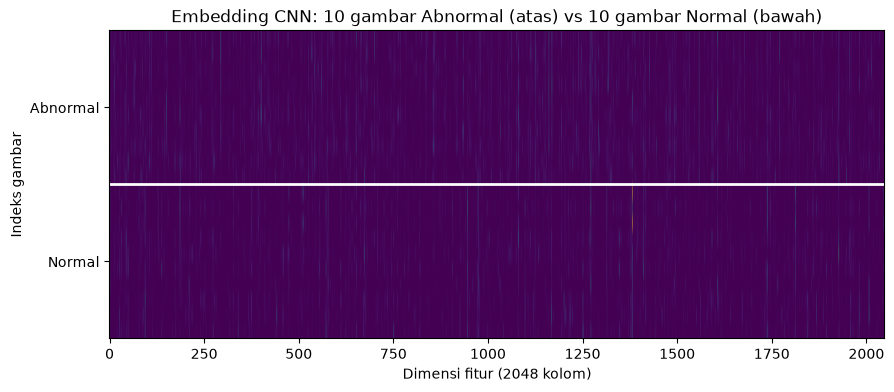

In [10]:
import matplotlib.pyplot as plt

idx_abnormal = np.where(y_train == "Abnormal")[0][:10]
idx_normal = np.where(y_train == "Normal")[0][:10]
idx_sample = np.concatenate([idx_abnormal, idx_normal])

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(X_train[idx_sample], aspect="auto", cmap="viridis")
ax.axhline(y=9.5, color="white", linewidth=2)
ax.set_title("Embedding CNN: 10 gambar Abnormal (atas) vs 10 gambar Normal (bawah)")
ax.set_xlabel("Dimensi fitur (2048 kolom)")
ax.set_ylabel("Indeks gambar")
ax.set_yticks([4.5, 14.5])
ax.set_yticklabels(["Abnormal", "Normal"])
plt.show()

### 3.2 Ekstraksi Fitur Handcrafted (Warna)


In [11]:
import feature_extraction_handcrafted

feature_extraction_handcrafted.main()

Data latih: 400, Data uji: 100
Ekstraksi fitur handcrafted data latih...
  50/400 gambar diproses
  100/400 gambar diproses
  150/400 gambar diproses


  200/400 gambar diproses
  250/400 gambar diproses
  300/400 gambar diproses
  350/400 gambar diproses
  400/400 gambar diproses
Ekstraksi fitur handcrafted data uji...
  50/100 gambar diproses


  100/100 gambar diproses
Selesai. X_train: (400, 6), X_test: (100, 6)


In [12]:
X_train_hc = np.load(feature_extraction_handcrafted.OUTPUTS_DIR / "features_handcrafted_train.npy")
X_test_hc = np.load(feature_extraction_handcrafted.OUTPUTS_DIR / "features_handcrafted_test.npy")

print("Fitur handcrafted data latih:", X_train_hc.shape)
print("Fitur handcrafted data uji:", X_test_hc.shape)

kolom = ["mean_H", "std_H", "mean_S", "std_S", "mean_V", "std_V"]
pd.DataFrame(X_train_hc[:5], columns=kolom)

Fitur handcrafted data latih: (400, 6)
Fitur handcrafted data uji: (100, 6)


,mean_H,std_H,mean_S,std_S,mean_V,std_V
0,0.137401,0.097767,0.187894,0.112131,0.560943,0.122584
1,0.275823,0.392466,0.308669,0.124748,0.572906,0.120209
2,0.323181,0.426587,0.446723,0.149535,0.461708,0.210819
3,0.406918,0.431940,0.489816,0.235502,0.547516,0.142060
4,0.076496,0.094418,0.477629,0.152161,0.529367,0.197063


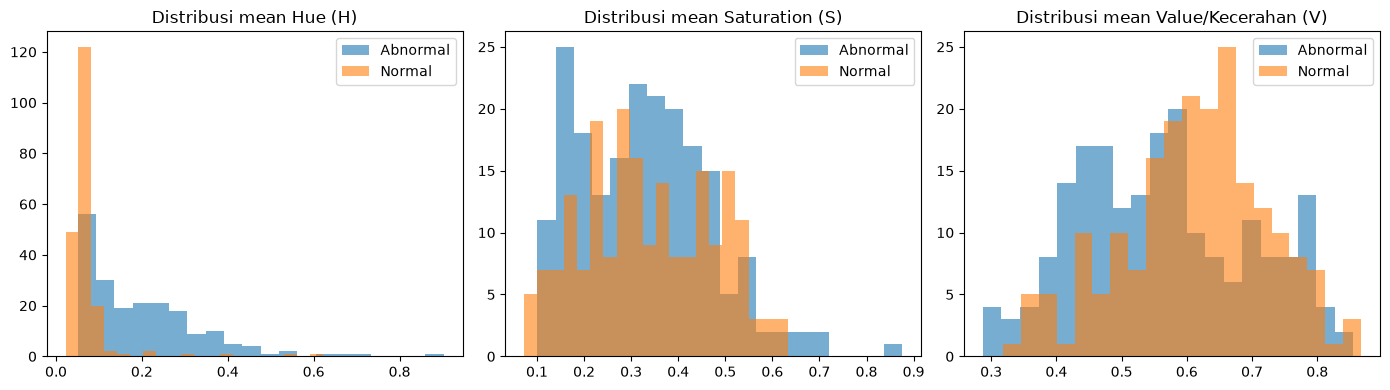

In [13]:
# bandingkan distribusi warna abnormal vs normal
y_train_arr = np.array([r["label"] for r in feature_extraction_handcrafted.load_manifest() if r["split"] == "train"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
nama_channel = ["Hue (H)", "Saturation (S)", "Value/Kecerahan (V)"]

for i, ax in enumerate(axes):
    idx_kolom = i * 2  # kolom mean tiap channel ada di index 0, 2, 4
    ax.hist(X_train_hc[y_train_arr == "Abnormal", idx_kolom], bins=20, alpha=0.6, label="Abnormal")
    ax.hist(X_train_hc[y_train_arr == "Normal", idx_kolom], bins=20, alpha=0.6, label="Normal")
    ax.set_title(f"Distribusi mean {nama_channel[i]}")
    ax.legend()

plt.tight_layout()
plt.show()

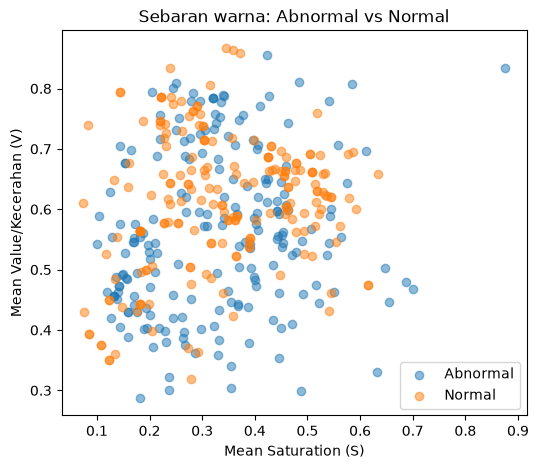

In [14]:
# scatter saturasi vs kecerahan, per kelas
plt.figure(figsize=(6, 5))
plt.scatter(X_train_hc[y_train_arr == "Abnormal", 2], X_train_hc[y_train_arr == "Abnormal", 4], alpha=0.5, label="Abnormal")
plt.scatter(X_train_hc[y_train_arr == "Normal", 2], X_train_hc[y_train_arr == "Normal", 4], alpha=0.5, label="Normal")
plt.xlabel("Mean Saturation (S)")
plt.ylabel("Mean Value/Kecerahan (V)")
plt.title("Sebaran warna: Abnormal vs Normal")
plt.legend()
plt.show()

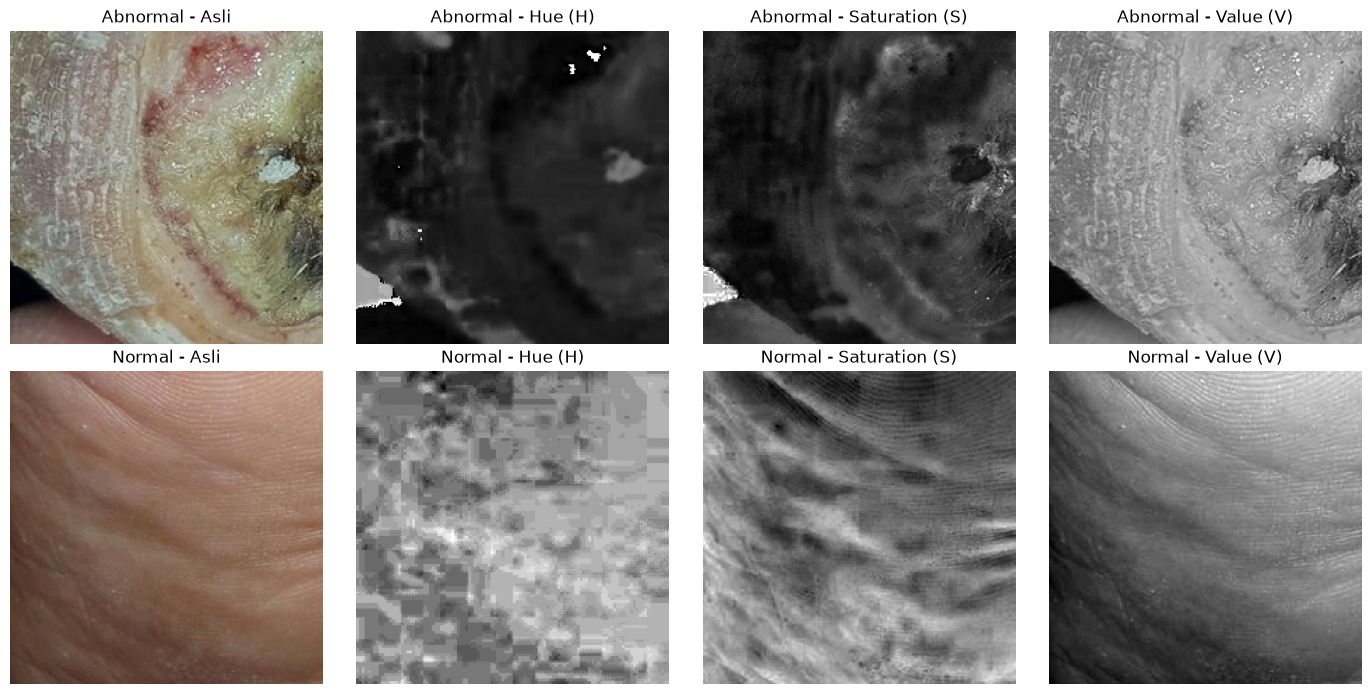

In [15]:
# bandingkan gambar asli dengan tiap channel HSV
from PIL import Image

manifest_rows = feature_extraction_handcrafted.load_manifest()
contoh_abnormal = next(r for r in manifest_rows if r["label"] == "Abnormal" and r["split"] == "train")
contoh_normal = next(r for r in manifest_rows if r["label"] == "Normal" and r["split"] == "train")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
nama_channel = ["Asli", "Hue (H)", "Saturation (S)", "Value (V)"]

for i, contoh in enumerate([contoh_abnormal, contoh_normal]):
    img_asli = Image.open(feature_extraction_handcrafted.SUBSET_DIR / contoh["label"] / contoh["filename"])
    arr_hsv = np.load(feature_extraction_handcrafted.PREPROCESSED_DIR / "hsv_normalized" / contoh["label"] / Path(contoh["filename"]).with_suffix(".npy"))

    axes[i, 0].imshow(img_asli)
    axes[i, 0].set_title(f"{contoh['label']} - {nama_channel[0]}")
    axes[i, 0].axis("off")

    for c in range(3):
        axes[i, c + 1].imshow(arr_hsv[:, :, c], cmap="gray")
        axes[i, c + 1].set_title(f"{contoh['label']} - {nama_channel[c + 1]}")
        axes[i, c + 1].axis("off")

plt.tight_layout()
plt.show()